In [1]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
DEVICE = 1
DECODER_TYPE = 'nar-enc'
SEED = 42

In [3]:
import torch
torch.random.manual_seed(SEED)
selected_labels = torch.arange(344)[torch.randperm(344)][:10]
selected_points = torch.randperm(2500)[:100]
subsampled_labels = selected_labels.repeat_interleave(100).numpy()

In [4]:
import torch
from src.data import QuickDrawDataset

dataset = QuickDrawDataset("../../sketch_representations/data/quickdraw", split="test")
test_loader = torch.utils.data.DataLoader(dataset, batch_size=512, collate_fn=QuickDrawDataset.collate_fn_padd, 
                                           num_workers=8)

In [5]:
import pickle as pkl
from sklearn.manifold import TSNE
from src.lightning_models import LtSketchReconstruction
from src.models import Sketchformer, BlockConfig, PosEmbeddingConfig
from src.data import InputHandler, OutputHandler

projs = {}

for coord_type in ["rel_rel", "rel_abs", "abs_rel", "abs_abs"]:
    with open(f"../../sketch_representations/results/experiment2/{coord_type}_{DECODER_TYPE}_{SEED}.pkl", "rb") as file:
        results = pkl.load(file)

    checkpoint = torch.load(f"../../sketch_representations/checkpoints/experiment2/{coord_type}_{DECODER_TYPE}_{SEED}/best.ckpt")

    sketchformer = Sketchformer(
        hidden_dim=results['args']['hidden_dim'],
        num_encoder_layers=results['args']['num_encoder_layers'],
        num_decoder_layers=results['args']['num_decoder_layers'],
        decoder_type=results['args']['decoder_type'],
        block_config=BlockConfig(
            dropout=results['args']['hidden_dropout']
        ),
        pos_embedding_config=PosEmbeddingConfig(
            pen_state=results['args']['pen_state'], 
            stroke_embedding=results['args']['stroke_embedding'], 
            sketch_pos=results['args']['sketch_pos'],
            stroke_pos=results['args']['stroke_pos']
        )
    )


    input_handler = InputHandler(input_relative_coords=results['args']['input_relative_coords'], output_relative_coords=results['args']['output_relative_coords'], autoencoder=True, autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"])
    output_handler = OutputHandler(output_relative_coords=results['args']['output_relative_coords'], autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"])
    model = LtSketchReconstruction(sketchformer, input_handler, output_handler, results['args']['lr'])
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    model = model.to("cuda:1")
    sketchformer = model.sketchformer
    sketchformer.decoder = None
    sketchformer.ln_decoder = None

    embeddings = {int(label): [] for label in selected_labels}

    for batch in test_loader:
        batch = {k: v.to("cuda:1") for k,v in batch.items()}
        model_input = input_handler(batch)
        x_enc = model_input['encoder']
        
        with torch.no_grad():
            h_sketch = sketchformer.encode(x_enc['pos'], x_enc['pos_info'], x_enc['token_id'], x_enc['mask'])

        for label in selected_labels:
            if (batch['label'] == label).sum() == 0: continue
            embeddings[int(label)].append(h_sketch[batch['label'] == label].cpu())


    subsampled_embeddings = torch.cat([torch.cat(embeddings[int(label)], dim=0)[selected_points] for label in selected_labels], dim=0)
    projs[coord_type] = TSNE(random_state=SEED).fit_transform(subsampled_embeddings)


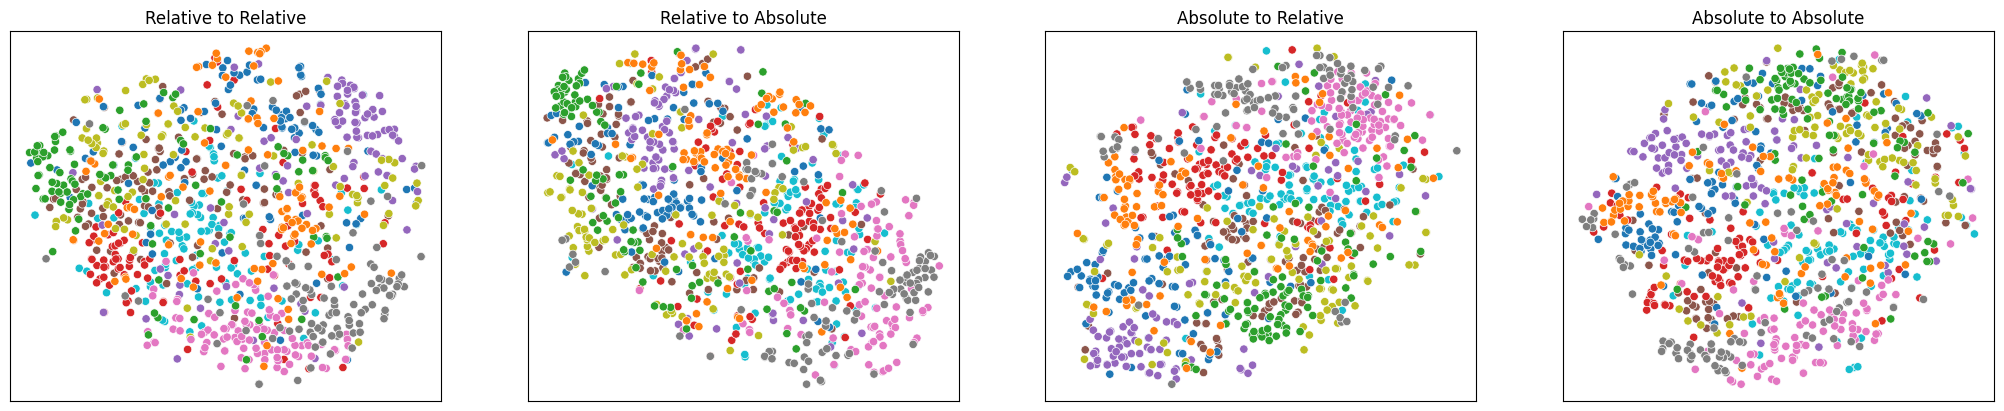

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 4, figsize=(6.4 * 4, 4.8 * 1))

for i, coord_type in enumerate([('rel_rel', 'Relative to Relative'), ('rel_abs', 'Relative to Absolute'), ('abs_rel', 'Absolute to Relative'), ('abs_abs', 'Absolute to Absolute')]):
    axis[i].set_title(coord_type[1])
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    sns.scatterplot(x=projs[coord_type[0]][:, 0], y=projs[coord_type[0]][:, 1], hue=subsampled_labels, ax=axis[i], palette="tab10", legend=False)